# Systematics from grid histogram counts

Loads ``syst_hists`` from the grid histcounts campaign, **stream-sums** into dense
rate/xsec arrays (never concatenates all long DataFrames), then builds
cov / corr / fractional uncertainties.

Default campaign (override with ``NUMUCC_SYST_HIST_ROOT``):
``…/cafpyana_tmp/syst_histcounts_full_2026_09_07_012239/``
(MC GENIE + MC GENIE Ar23p + dirt; MC Flux/G4 on grid were killed — use from-df).

## Final observables only (faster)

Default ``COV_VARS`` = ``integrated``, ``tki-del_Tp``, ``tki-del_alpha``, ``tki-del_phi``
(user shorthand ``tki-alpha`` / ``tki-phi`` → ``tki-del_*``). Cut-stage hists are skipped
in unpack/cov (~5% of rows). HDF Fixed format still reads each whole file, so full-stats
wall time is still dominated by I/O — but post-process / cov is ~10× cheaper.

## How to load without OOM

1. **Do not** call ``load_syst_hists_from_glob`` on thousands of GENIE files if you
   only need covs — even the streaming long-DF path keeps a huge accumulator.
2. **Do** use ``stream_sum_genie_dense`` → ``build_genie_covs_from_dense``:
   one file at a time → unpack → add into dense ``{cv, univ}`` / xsec tensors → drop.
   Peak RAM ≈ **one file** (~10 GiB for Spring MC GENIE) + dense state.
3. Optional: ``GENIE_MAX_FILES`` for a smoke subset; full Spring GENIE is ~1k+ files
   and takes many hours of I/O — prefer overnight / pre-sum to a dense pickle.

Binning/labels: frozen VariableConfig from job HDF ``var_configs`` /
``variable_configs.json`` (not live ``variable_configs.py``).

## Slim products (do not double-count)

Prefer ``slim`` **or** the sum of per-knob multisim covs — not both.

## GENIE rate vs xsec

* **Rate** — reweighted selected reco yields → keys ``{knob}_rate``, ``genie_rate``
* **Xsec** — $N_u = R(u)\,N_{\mathrm{gen}}^{\mathrm{CV}} + (b_u-b_{\mathrm{CV}})$ → ``{knob}``, ``genie``


In [2]:
# Host / memory available to this kernel
import os
import socket

def _meminfo_gb():
    out = {}
    with open("/proc/meminfo") as f:
        for line in f:
            key, val = line.split(":", 1)
            out[key] = int(val.split()[0]) / (1024**2)  # kB -> GiB
    return out

_m = _meminfo_gb()
_cgroup_limit = None
for _path in (
    "/sys/fs/cgroup/memory.max",  # cgroup v2
    "/sys/fs/cgroup/memory/memory.limit_in_bytes",  # cgroup v1
):
    if os.path.exists(_path):
        _raw = open(_path).read().strip()
        if _raw not in ("max", "") and _raw.isdigit():
            _lim = int(_raw)
            # ignore unrealistically large "unlimited" sentinels
            if _lim < (1 << 60):
                _cgroup_limit = _lim / (1024**3)
        break

print(f"host          = {socket.gethostname()}")
print(f"MemTotal      = {_m['MemTotal']:.2f} GiB")
print(f"MemAvailable  = {_m['MemAvailable']:.2f} GiB")
print(f"MemFree       = {_m['MemFree']:.2f} GiB")
if _cgroup_limit is not None:
    print(f"cgroup limit  = {_cgroup_limit:.2f} GiB")


host          = jupyter-munjung
MemTotal      = 477.09 GiB
MemAvailable  = 460.00 GiB
MemFree       = 380.70 GiB
cgroup limit  = 192.00 GiB


In [ ]:
from __future__ import annotations

import glob
import os
from collections import defaultdict
import sys
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana') # absolute path for running on EAF

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from makedf.geniesyst import GENIE_KNOB_GROUPS
from analysis_village.numucc_1p0pi.utils import plot_heatmap
from analysis_village.numucc_1p0pi.syst_histcounts import (
    VAR_CONFIG_SNAPSHOT_JSON_NAME,
    build_genie_covs_from_dense,
    combine_indep_knob_frac_covs,
    finalize_genie_xsec_cv,
    finalize_genie_xsec_univ,
    load_syst_hists_from_glob,
    load_var_config_snapshot_json,
    load_var_configs_from_df_file,
    load_var_configs_from_glob,
    nbins_by_var_from_configs,
    rate_cov_from_univ_cv,
    scale_cov_by_contamination,
    stream_sum_genie_dense,
    stream_sum_rate_dense,
    unisim_cov_from_cv_and_var,
    unpack_rate_from_df,
    unpack_xsec_from_df,
)

# --- pnfs scratch defaults (override with NUMUCC_SYST_HIST_ROOT) ---
SCRATCH = os.environ.get(
    "NUMUCC_SYST_SCRATCH",
    "/pnfs/sbnd/scratch/users/munjung",
)
# Full histcounts campaign with MC GENIE + Ar23p (+ dirt).
HIST_ROOT = os.environ.get(
    "NUMUCC_SYST_HIST_ROOT",
    os.path.join(SCRATCH, "cafpyana_tmp", "syst_histcounts_full_2026_09_07_012239"),
)
# Cap files for smoke tests (0 = all). Example: GENIE_MAX_FILES=5
GENIE_MAX_FILES = int(os.environ.get("GENIE_MAX_FILES", "0"))
# Search only this campaign by default (avoid mixing smoke / older cafpyana_out).
HIST_SEARCH_ROOTS = [HIST_ROOT]
_extra = os.environ.get("NUMUCC_SYST_HIST_EXTRA_ROOTS", "")
if _extra.strip():
    HIST_SEARCH_ROOTS.extend(p for p in _extra.split(":") if p)
_seen = set()
HIST_SEARCH_ROOTS = [
    r for r in HIST_SEARCH_ROOTS if not (r in _seen or _seen.add(r))
]

XSEC_UNIT = 1.0
PLOT_VAR = os.environ.get("NUMUCC_SYST_PLOT_VAR", "integrated")  # change as needed
COV_KIND = os.environ.get("NUMUCC_SYST_COV_KIND", "rate")  # "rate" or "xsec"
# Final selected observables only (skip cut-stage). Override with NUMUCC_SYST_COV_VARS=a,b,c
_cov_vars_env = os.environ.get("NUMUCC_SYST_COV_VARS", "").strip()
COV_VARS = (
    [v.strip() for v in _cov_vars_env.split(",") if v.strip()]
    if _cov_vars_env
    else ["integrated", "tki-del_Tp", "tki-del_alpha", "tki-del_phi"]
)

# Filled after discovery from job-output snapshot (HDF ``var_configs`` / JSON).
# Do not import live ``variable_configs.py`` — it can change after jobs ran.
VAR_CONFIGS: dict = {}
NBINS_BY_VAR: dict[str, int] = {}
print("SCRATCH =", SCRATCH)
print("HIST_ROOT =", HIST_ROOT)
print("HIST_SEARCH_ROOTS =", HIST_SEARCH_ROOTS)
print("PLOT_VAR =", PLOT_VAR, "COV_KIND =", COV_KIND)
print("COV_VARS =", COV_VARS)


## Run Flux / G4 histcounts from sel_all DFs (this kernel)

Reprocesses cached weight ``.df`` files on **this** machine (uses the kernel host CPUs/RAM — e.g. EAF). Same layout as ``run_syst_histcounts_from_df.sh``.

Set ``FAMILY`` / ``WORKERS`` / ``BACKGROUND`` below, then run the next cell. Point ``NUMUCC_SYST_HIST_EXTRA_ROOTS`` (or append to ``HIST_SEARCH_ROOTS``) at the printed ``out_root`` when loading covariances.


In [ ]:
from analysis_village.numucc_1p0pi.scripts.run_syst_histcounts_from_df import (
    run_histcounts_from_df,
    tail_log,
)

# --- configure ---
RUN_HISTCOUNTS_FROM_DF = False  # set True to launch
FAMILY = "G4"                   # "Flux" | "G4" | "both"
WORKERS = 10
N_UNIVERSE = 1000
MAX_FILES = 0                   # 0 = all; use 2 for a smoke test
BACKGROUND = True               # True: nohup-style detach; False: block in this cell
# OUT_ROOT = None               # default: new stamp under pnfs scratch
# OUT_ROOT = "/pnfs/sbnd/scratch/users/munjung/cafpyana_tmp/syst_histcounts_from_df_2026_09_07_140239"

if RUN_HISTCOUNTS_FROM_DF:
    HISTCOUNTS_FROM_DF = run_histcounts_from_df(
        family=FAMILY,
        workers=WORKERS,
        n_universe=N_UNIVERSE,
        max_files=MAX_FILES,
        # out_root=OUT_ROOT,
        background=BACKGROUND,
    )
    print("out_root =", HISTCOUNTS_FROM_DF.out_root)
    if HISTCOUNTS_FROM_DF.background:
        print("pid      =", HISTCOUNTS_FROM_DF.pid)
        print("log      =", HISTCOUNTS_FROM_DF.log_path)
        print("--- log tail ---")
        print(tail_log(HISTCOUNTS_FROM_DF, n_lines=20))
else:
    print("Skipped (set RUN_HISTCOUNTS_FROM_DF = True to launch).")
    print("Example: FAMILY=%r WORKERS=%d BACKGROUND=%s" % (FAMILY, WORKERS, BACKGROUND))


## 1. Discover histcount files

Default root: ``syst_histcounts_full_2026_09_07_012239`` (MC GENIE / Ar23p / dirt).

``hist_mc_genie_*`` is split into Spring GENIE vs ``Ar23p`` (do not mix basename globs carelessly).
MC Flux/G4 grid dirs may be empty/killed — Flux/G4 come from the from-df campaign via
``NUMUCC_SYST_HIST_EXTRA_ROOTS`` when ready.

| tag | content |
|-----|--------|
| ``hist_mc_genie_*`` / ``hist_dirt_genie`` | GENIE (+ slim) |
| ``hist_mc_flux`` / ``hist_dirt_flux`` | Flux |
| ``hist_mc_g4`` / ``hist_dirt_g4`` | G4 |
| ``hist_offbeam`` / ``hist_intime`` | cosmics unisim |

Stub job dirs (early failed 1-file runs) are ignored by keeping the latest
job stamp per ``*.df`` basename.

**Detector (matched events — not histcounts):**
- **WireMod** — precomputed cov from `wiremod.ipynb`:
  ``…/systematics-final/WireMod/Detector/detector_syst_dict.npz``
- **DENT** — matched **sel_all** CV vs DENT hist cache from `dent_compare.py`
  (``DENT-updated/cache/dent_sel_all_hists.pkl``; walk to ``2prong-mup``)


In [2]:
def _job_stamp(path: str) -> str:
    """``YYYY_MM_DD_HHMMSS`` from parent dir ``…/stamp__tag/file.df`` (else '')."""
    parent = os.path.basename(os.path.dirname(path))
    return parent.split("__", 1)[0] if "__" in parent else parent


def _dedupe_latest_basename(files: list[str]) -> list[str]:
    """If stub + full job dirs both have ``hist_*_0.df``, keep the later stamp."""
    best: dict[str, tuple[str, str]] = {}
    for f in files:
        base = os.path.basename(f)
        stamp = _job_stamp(f)
        prev = best.get(base)
        if prev is None or stamp > prev[0]:
            best[base] = (stamp, f)
    return sorted(p for _, p in best.values())


def glob_hist_dfs(*tags: str, roots=None) -> list[str]:
    """Match ``*.df`` under pnfs scratch search roots (default: ``HIST_SEARCH_ROOTS``)."""
    if roots is None:
        roots = HIST_SEARCH_ROOTS
    files = []
    for root in roots:
        if not root or not os.path.isdir(root):
            continue
        for tag in tags:
            pats = [
                os.path.join(root, f"*{tag}*.df"),
                os.path.join(root, "**", f"*{tag}*.df"),
            ]
            for p in pats:
                files.extend(glob.glob(p, recursive=True))
    return _dedupe_latest_basename(sorted(set(files)))


# Neutrino-weighted: split MC + dirt (genie / flux / g4) jobs
# Keep Ar23p separate — basename ``hist_mc_genie_*`` also matches Ar23p.
MC_GENIE_AR23P_FILES = glob_hist_dfs("hist_mc_genie_Ar23p")
_mc_genie_raw = glob_hist_dfs("hist_mc_genie_", "hist_mc_all")
MC_GENIE_FILES = sorted(
    f
    for f in _mc_genie_raw
    if "Ar23p" not in os.path.basename(f) and "genie_Ar23p" not in f
)
MC_FLUX_FILES = glob_hist_dfs("hist_mc_flux")
MC_G4_FILES = glob_hist_dfs("hist_mc_g4")
DIRT_GENIE_FILES = glob_hist_dfs("hist_dirt_genie")
DIRT_FLUX_FILES = glob_hist_dfs("hist_dirt_flux")
DIRT_G4_FILES = glob_hist_dfs("hist_dirt_g4")
DIRT_ALL_FILES = glob_hist_dfs("hist_dirt_all")  # legacy single-job dirt
DIRT_FILES = sorted(
    set(DIRT_GENIE_FILES + DIRT_FLUX_FILES + DIRT_G4_FILES + DIRT_ALL_FILES)
)
NEUTRINO_FILES = sorted(
    set(
        MC_GENIE_FILES
        + MC_GENIE_AR23P_FILES
        + MC_FLUX_FILES
        + MC_G4_FILES
        + DIRT_FILES
    )
)

OFFBEAM_FILES = glob_hist_dfs("hist_offbeam")
INTIME_FILES = glob_hist_dfs("hist_intime")

# Matched-event detector systs (WireMod / DENT) — not from histcounts jobs
SYST_FINAL_ROOT = os.environ.get(
    "NUMUCC_SYST_FINAL_ROOT",
    "/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final",
)
WIREMOD_DETECTOR_NPZ = os.environ.get(
    "NUMUCC_WIREMOD_DETECTOR_NPZ",
    os.path.join(SYST_FINAL_ROOT, "WireMod", "Detector", "detector_syst_dict.npz"),
)
# Prefer DENT-updated sel_all cache; fall back to older DENT runs.
_DENT_CANDIDATES = [
    os.environ.get("NUMUCC_DENT_OUT_BASE", ""),
    os.path.join(SYST_FINAL_ROOT, "DENT-updated"),
    os.path.join(SYST_FINAL_ROOT, "DENT-morestats"),
    os.path.join(SYST_FINAL_ROOT, "DENT"),
]

def _dent_ready(base: str) -> bool:
    # Final + cut-stage vars live in the sel_all hist cache (no sel_mup pass).
    return bool(base) and os.path.isfile(os.path.join(base, "cache", "dent_sel_all_hists.pkl"))

DENT_OUT_BASE = next((p for p in _DENT_CANDIDATES if _dent_ready(p)), "")
DENT_ALL_HISTS_PKL = os.environ.get(
    "NUMUCC_DENT_ALL_HISTS",
    os.path.join(DENT_OUT_BASE, "cache", "dent_sel_all_hists.pkl") if DENT_OUT_BASE else "",
)
# Legacy alias (older caches); unused once DENT-updated sel_all cache exists.
DENT_MUP_HISTS_PKL = os.environ.get("NUMUCC_DENT_MUP_HISTS", "")

for label, files in [
    ("mc_genie", MC_GENIE_FILES),
    ("mc_genie_Ar23p", MC_GENIE_AR23P_FILES),
    ("mc_flux", MC_FLUX_FILES),
    ("mc_g4", MC_G4_FILES),
    ("dirt_genie", DIRT_GENIE_FILES),
    ("dirt_flux", DIRT_FLUX_FILES),
    ("dirt_g4", DIRT_G4_FILES),
    ("dirt_all", DIRT_ALL_FILES),
    ("neutrino_all", NEUTRINO_FILES),
    ("offbeam", OFFBEAM_FILES),
    ("intime", INTIME_FILES),
]:
    print(f"{label:14s} {len(files):5d} files")
print("WireMod NPZ:  ", WIREMOD_DETECTOR_NPZ, "exists=", os.path.isfile(WIREMOD_DETECTOR_NPZ))
print("DENT out base:", DENT_OUT_BASE or "(none)")
print("DENT all pkl: ", DENT_ALL_HISTS_PKL, "exists=", bool(DENT_ALL_HISTS_PKL and os.path.isfile(DENT_ALL_HISTS_PKL)))

# Frozen VariableConfig: prefer campaign JSON, else a few hist files (not all).
_cfg_probe = (MC_GENIE_FILES[:3] + MC_GENIE_AR23P_FILES[:1] + DIRT_GENIE_FILES[:1])
VAR_CONFIGS = {}
for root in HIST_SEARCH_ROOTS:
    snap = os.path.join(root, VAR_CONFIG_SNAPSHOT_JSON_NAME)
    if os.path.isfile(snap):
        VAR_CONFIGS = load_var_config_snapshot_json(snap)
        print("loaded VariableConfig snapshot:", snap)
        break
if not VAR_CONFIGS:
    for p in _cfg_probe:
        try:
            VAR_CONFIGS = load_var_configs_from_df_file(p)
        except Exception:
            VAR_CONFIGS = {}
        if VAR_CONFIGS:
            print("loaded VariableConfig from", p)
            break
if not VAR_CONFIGS:
    VAR_CONFIGS = load_var_configs_from_glob(_cfg_probe)
NBINS_BY_VAR = nbins_by_var_from_configs(VAR_CONFIGS)
print(
    f"VAR_CONFIGS: {len(VAR_CONFIGS)} vars"
    + (f" (e.g. {sorted(VAR_CONFIGS)[:3]}…)" if VAR_CONFIGS else " — missing; re-run hist jobs")
)
print(f"GENIE_MAX_FILES = {GENIE_MAX_FILES} (0 = all)")


mc_genie        1500 files
mc_flux         2500 files
mc_g4           2500 files
dirt_genie       800 files
dirt_flux        800 files
dirt_g4          800 files
dirt_all           0 files
neutrino_all    8900 files
offbeam          600 files
intime           600 files
WireMod NPZ:   /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/WireMod/Detector/detector_syst_dict.npz exists= True
DENT out base: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/DENT-updated
DENT all pkl:  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/DENT-updated/cache/dent_sel_all_hists.pkl exists= True
VAR_CONFIGS: 53 vars (e.g. ['chi2_avg_mu__at_2prong-muX', 'chi2_avg_mu__at_2prong-mup', 'chi2_avg_mu__at_2prong-vtxdist']…)


## 2. Build covariances from histcounts

In [3]:
SLIM_SKIP = {
    "slim", "slim_multisim",
    "Flux_slim", "Flux_slim_multisim",
    "G4_slim", "G4_slim_multisim",
    "GENIE", "Flux", "G4",
}


def knobs_for_genie_mode(mode: str) -> set[str]:
    return set(GENIE_KNOB_GROUPS.get(mode, []))


def pack_frac_diag(pack: dict) -> np.ndarray:
    return np.sqrt(np.clip(np.diag(pack["cov_frac"]), 0.0, None))


def build_genie_covs_from_hist_df(hist_df: pd.DataFrame, *, xsec_unit: float = 1.0):
    """Per-knob + totals. Keys: ``{knob}_rate``, ``{knob}`` (xsec), ``genie_rate``, ``genie``."""
    rate = unpack_rate_from_df(hist_df, family="GENIE", nbins_by_var=NBINS_BY_VAR)
    xsec = unpack_xsec_from_df(hist_df, family="GENIE", nbins_by_var=NBINS_BY_VAR)

    by_var: dict = defaultdict(dict)
    rate_packs_by_var: dict = defaultdict(list)
    xsec_packs_by_var: dict = defaultdict(list)
    cv_rate_by_var: dict = {}
    cv_xsec_by_var: dict = {}

    for knob, vars_d in rate.items():
        for slug, pack in vars_d.items():
            if pack["univ"].size == 0:
                continue
            rp = rate_cov_from_univ_cv(pack["univ"], pack["cv"])
            by_var[slug][f"{knob}_rate"] = rp
            if knob not in SLIM_SKIP:
                rate_packs_by_var[slug].append(rp)
            cv_rate_by_var[slug] = pack["cv"]

    for knob, vars_d in xsec.items():
        for slug, acc in vars_d.items():
            univ = finalize_genie_xsec_univ(acc, xsec_unit=xsec_unit)
            cv = finalize_genie_xsec_cv(acc, xsec_unit=xsec_unit, bkgd_subtract=True)
            if univ.size == 0:
                continue
            xp = rate_cov_from_univ_cv(univ, cv)
            by_var[slug][knob] = xp
            if knob not in SLIM_SKIP:
                xsec_packs_by_var[slug].append(xp)
            cv_xsec_by_var[slug] = cv

    for slug in set(rate_packs_by_var) | set(xsec_packs_by_var):
        if slug in rate_packs_by_var:
            by_var[slug]["genie_rate"] = combine_indep_knob_frac_covs(
                rate_packs_by_var[slug], cv_rate_by_var[slug]
            )
        if slug in xsec_packs_by_var:
            by_var[slug]["genie"] = combine_indep_knob_frac_covs(
                xsec_packs_by_var[slug], cv_xsec_by_var[slug]
            )
    return dict(by_var)


def build_multisim_rate_covs(hist_df: pd.DataFrame, family: str):
    rate = unpack_rate_from_df(hist_df, family=family, nbins_by_var=NBINS_BY_VAR)
    by_var: dict = defaultdict(dict)
    packs_by_var: dict = defaultdict(list)
    cv_by_var: dict = {}
    for knob, vars_d in rate.items():
        for slug, pack in vars_d.items():
            if pack["univ"].size == 0:
                continue
            rp = rate_cov_from_univ_cv(pack["univ"], pack["cv"])
            by_var[slug][knob] = rp
            if knob not in SLIM_SKIP:
                packs_by_var[slug].append(rp)
            cv_by_var[slug] = pack["cv"]
    key = family.lower()
    for slug, packs in packs_by_var.items():
        by_var[slug][key] = combine_indep_knob_frac_covs(packs, cv_by_var[slug])
    return dict(by_var)




def build_multisim_rate_covs_from_dense(rate: dict, family: str):
    """Like ``build_multisim_rate_covs`` but from dense ``rate[knob][var]={cv,univ}``."""
    by_var: dict = defaultdict(dict)
    packs_by_var: dict = defaultdict(list)
    cv_by_var: dict = {}
    for knob, vars_d in rate.items():
        for slug, pack in vars_d.items():
            if pack["univ"].size == 0:
                continue
            rp = rate_cov_from_univ_cv(pack["univ"], pack["cv"])
            by_var[slug][knob] = rp
            if knob not in SLIM_SKIP:
                packs_by_var[slug].append(rp)
            cv_by_var[slug] = pack["cv"]
    key = family.lower()
    for slug, packs in packs_by_var.items():
        by_var[slug][key] = combine_indep_knob_frac_covs(packs, cv_by_var[slug])
    return dict(by_var)

def unisim_cv_counts(hist_df: pd.DataFrame) -> dict[str, np.ndarray]:
    rate = unpack_rate_from_df(hist_df, family="UNISIM", nbins_by_var=NBINS_BY_VAR)
    out = {}
    for _knob, vars_d in rate.items():
        for slug, pack in vars_d.items():
            out[slug] = np.asarray(pack["cv"], dtype=float)
    return out


def build_unisim_covs(cv_counts: dict, var_counts: dict) -> dict:
    out = {}
    for slug in sorted(set(cv_counts) & set(var_counts)):
        out[slug] = unisim_cov_from_cv_and_var(cv_counts[slug], var_counts[slug])
    return out


def sum_mode_frac_covs(
    by_var_knob: dict, mode: str, *,
    kind: str = "rate",
    cv: np.ndarray | None = None,
) -> dict | None:
    """Sum independent knob frac-covs belonging to a GENIE mode (CCQE, MEC, …)."""
    want = knobs_for_genie_mode(mode)
    packs = []
    for key, pack in by_var_knob.items():
        if key in ("genie", "genie_rate") or key in SLIM_SKIP:
            continue
        knob = key[:-5] if key.endswith("_rate") else key
        is_rate_key = key.endswith("_rate")
        if kind == "rate":
            # Prefer explicit ``*_rate`` keys when present
            if f"{knob}_rate" in by_var_knob and not is_rate_key:
                continue
            if not is_rate_key and f"{knob}_rate" not in by_var_knob:
                pass  # rate-only families store under knob name
            elif not is_rate_key:
                continue
        if kind == "xsec" and is_rate_key:
            continue
        if knob not in want:
            continue
        packs.append(pack)
    if not packs:
        return None
    if cv is None:
        # Fall back to sqrt of absolute cov diagonal / frac (reconstruction)
        cf = np.asarray(packs[0]["cov_frac"], dtype=float)
        ca = np.asarray(packs[0]["cov"], dtype=float)
        with np.errstate(divide="ignore", invalid="ignore"):
            cv = np.sqrt(np.clip(np.diag(ca) / np.clip(np.diag(cf), 1e-30, None), 0, None))
            cv = np.nan_to_num(cv, nan=1.0)
    return combine_indep_knob_frac_covs(packs, cv)

# --- Matched-event detector loaders (WireMod NPZ / DENT hist pickles) ---
import pickle

WIREMOD_NPZ_TAG_LABEL = {
    "wiremod_yz": "WireModYZ",
    "wiremod_xtxw": "WireModXTXW",
}


def load_wiremod_detector_covs(npz_path: str) -> dict:
    """Load matched sel_mup WireMod envelope unisim from ``detector_syst_dict.npz``."""
    if not npz_path or not os.path.isfile(npz_path):
        return {}
    blob = np.load(npz_path, allow_pickle=True)
    if "detector_by_wiremod" not in blob.files:
        raise KeyError(f"{npz_path} missing detector_by_wiremod")
    by_var = blob["detector_by_wiremod"].item()
    out: dict = defaultdict(dict)
    for slug, per_tag in by_var.items():
        if not isinstance(per_tag, dict):
            continue
        for tag, pack in per_tag.items():
            label = WIREMOD_NPZ_TAG_LABEL.get(tag, tag)
            out[label][slug] = {
                "cov": np.asarray(pack["cov"], dtype=float),
                "cov_frac": np.asarray(pack["cov_frac"], dtype=float),
                "corr": np.asarray(pack.get("corr", pack.get("corr_frac", [])), dtype=float),
            }
    return dict(out)


def _load_dent_hists_pkl(pkl_path: str) -> dict:
    """Load dent_compare hist cache (hists['cv'|'dent'][var] -> counts)."""
    if not pkl_path or not os.path.isfile(pkl_path):
        return {}
    with open(pkl_path, "rb") as fh:
        payload = pickle.load(fh)
    return payload.get("hists", {}) if isinstance(payload, dict) else {}


def load_dent_covs_from_hists(*pkl_paths: str) -> dict:
    """Build DENT unisim covs from matched CV vs DENT histogram caches."""
    out = {}
    for pkl_path in pkl_paths:
        hists = _load_dent_hists_pkl(pkl_path)
        if not hists or "cv" not in hists or "dent" not in hists:
            continue
        for slug in hists["cv"]:
            if slug not in hists["dent"]:
                continue
            if slug in out:
                continue  # prefer first path (sel_mup listed before sel_all)
            try:
                out[slug] = unisim_cov_from_cv_and_var(
                    np.asarray(hists["cv"][slug], dtype=float),
                    np.asarray(hists["dent"][slug], dtype=float),
                )
            except Exception as exc:
                print(f"[warn] DENT cov skip {slug} from {pkl_path}: {exc}")
    return out


In [ ]:
# --- GENIE (Spring + Ar23p + dirt): stream-sum dense, then covs ---
# Never concat all long DFs — peak RAM ≈ one Spring GENIE file + dense accumulators.
genie_cov = {}
flux_cov = {}
g4_cov = {}
genie_rate_dense = {}
genie_xsec_dense = {}

_genie_paths = (
    list(MC_GENIE_FILES) + list(MC_GENIE_AR23P_FILES) + list(DIRT_GENIE_FILES)
)
if GENIE_MAX_FILES > 0:
    # Prefer Spring, then Ar23p, then dirt within the file budget
    budget = GENIE_MAX_FILES
    n_spring = min(len(MC_GENIE_FILES), budget)
    budget -= n_spring
    n_ar = min(len(MC_GENIE_AR23P_FILES), budget)
    budget -= n_ar
    n_dirt = min(len(DIRT_GENIE_FILES), budget)
    _genie_paths = (
        list(MC_GENIE_FILES[:n_spring])
        + list(MC_GENIE_AR23P_FILES[:n_ar])
        + list(DIRT_GENIE_FILES[:n_dirt])
    )

if _genie_paths:
    n_sp = sum(1 for p in _genie_paths if "Ar23p" not in p and "dirt" not in p.lower())
    n_ar = sum(1 for p in _genie_paths if "Ar23p" in p)
    n_di = sum(1 for p in _genie_paths if "dirt" in p.lower())
    print(
        f"streaming GENIE dense from {len(_genie_paths)} files "
        f"(spring={n_sp}, Ar23p={n_ar}, dirt={n_di}; GENIE_MAX_FILES={GENIE_MAX_FILES})"
    )
    genie_rate_dense, genie_xsec_dense = stream_sum_genie_dense(
        _genie_paths,
        nbins_by_var=NBINS_BY_VAR,
        vars=COV_VARS,
        progress_every=max(1, min(25, len(_genie_paths))),
    )
    genie_cov = build_genie_covs_from_dense(
        genie_rate_dense,
        genie_xsec_dense,
        xsec_unit=XSEC_UNIT,
        slim_skip=SLIM_SKIP,
    )
    print("GENIE vars:", sorted(genie_cov))
    if PLOT_VAR in genie_cov:
        gkey = "genie_rate" if COV_KIND == "rate" else "genie"
        if gkey in genie_cov[PLOT_VAR]:
            frac = pack_frac_diag(genie_cov[PLOT_VAR][gkey])
            print(f"{PLOT_VAR} {gkey} frac[0] = {float(frac[0]):.4g}")
else:
    print("[warn] no MC GENIE / Ar23p / dirt_genie histcount files found")

# Flux / G4: only if files exist (grid MC flux/g4 may be empty; use from-df EXTRA_ROOTS)
if MC_FLUX_FILES or DIRT_FLUX_FILES:
    flux_paths = list(MC_FLUX_FILES) + list(DIRT_FLUX_FILES)
    print(f"streaming Flux rate dense from {len(flux_paths)} files")
    flux_rate = stream_sum_rate_dense(
        flux_paths, family="Flux", nbins_by_var=NBINS_BY_VAR, vars=COV_VARS, progress_every=25
    )
    flux_cov = build_multisim_rate_covs_from_dense(flux_rate, "Flux")
    print("Flux vars:", sorted(flux_cov))
else:
    print("[skip] no Flux hist files")

if MC_G4_FILES or DIRT_G4_FILES:
    g4_paths = list(MC_G4_FILES) + list(DIRT_G4_FILES)
    print(f"streaming G4 rate dense from {len(g4_paths)} files")
    g4_rate = stream_sum_rate_dense(
        g4_paths, family="G4", nbins_by_var=NBINS_BY_VAR, vars=COV_VARS, progress_every=25
    )
    g4_cov = build_multisim_rate_covs_from_dense(g4_rate, "G4")
    print("G4 vars:", sorted(g4_cov))
else:
    print("[skip] no G4 hist files")

# WireMod / DENT: matched-event systs (not unmatched histcounts)
detector_cov = {}
wm = load_wiremod_detector_covs(WIREMOD_DETECTOR_NPZ)
detector_cov.update(wm)
dent = load_dent_covs_from_hists(DENT_ALL_HISTS_PKL)
if dent:
    detector_cov["DENT"] = dent
print("detector:", {k: sorted(v) for k, v in detector_cov.items()})
if "integrated" in detector_cov.get("WireModYZ", {}):
    print(
        "WireModYZ integrated frac =",
        float(np.sqrt(np.clip(np.diag(detector_cov["WireModYZ"]["integrated"]["cov_frac"])[0], 0, None))),
    )
if "integrated" in detector_cov.get("DENT", {}):
    print(
        "DENT integrated frac =",
        float(np.sqrt(np.clip(np.diag(detector_cov["DENT"]["integrated"]["cov_frac"])[0], 0, None))),
    )

cosmics_cov = {}
INTIME_GATE_SCALE = 1.0  # set from hdr gates when available
FLAT_F = 0.05  # placeholder contamination; replace with measured f(bin)
if OFFBEAM_FILES and INTIME_FILES:
    # Unisim files are light — streaming long sum is OK
    off = unisim_cv_counts(load_syst_hists_from_glob(OFFBEAM_FILES))
    it = unisim_cv_counts(load_syst_hists_from_glob(INTIME_FILES))
    it = {k: v * INTIME_GATE_SCALE for k, v in it.items()}
    tmpl = build_unisim_covs(off, it)
    for slug, pack in tmpl.items():
        f = np.full(pack["cov"].shape[0], FLAT_F, dtype=float)
        cosmics_cov[slug] = scale_cov_by_contamination(pack, f)
print("cosmics vars:", sorted(cosmics_cov))


## 3. Covariance & correlation for a selected knob

Set ``SELECTED_KNOB`` to a CAF knob name (or ``slim`` / a WireMod tag).

SELECTED_KNOB = GENIEReWeight_SBN_v1_multisigma_DecayAngMEC


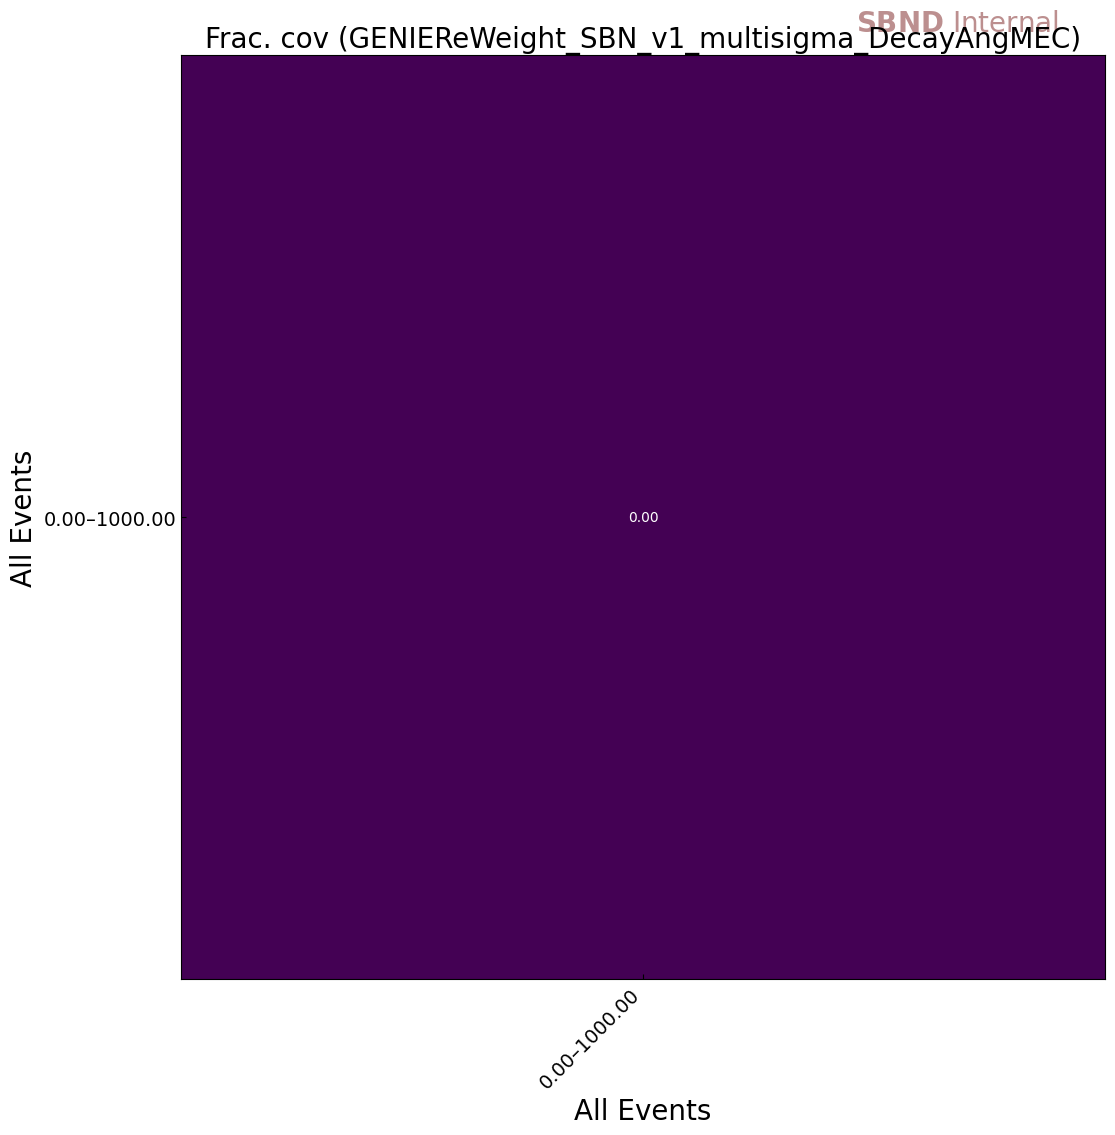

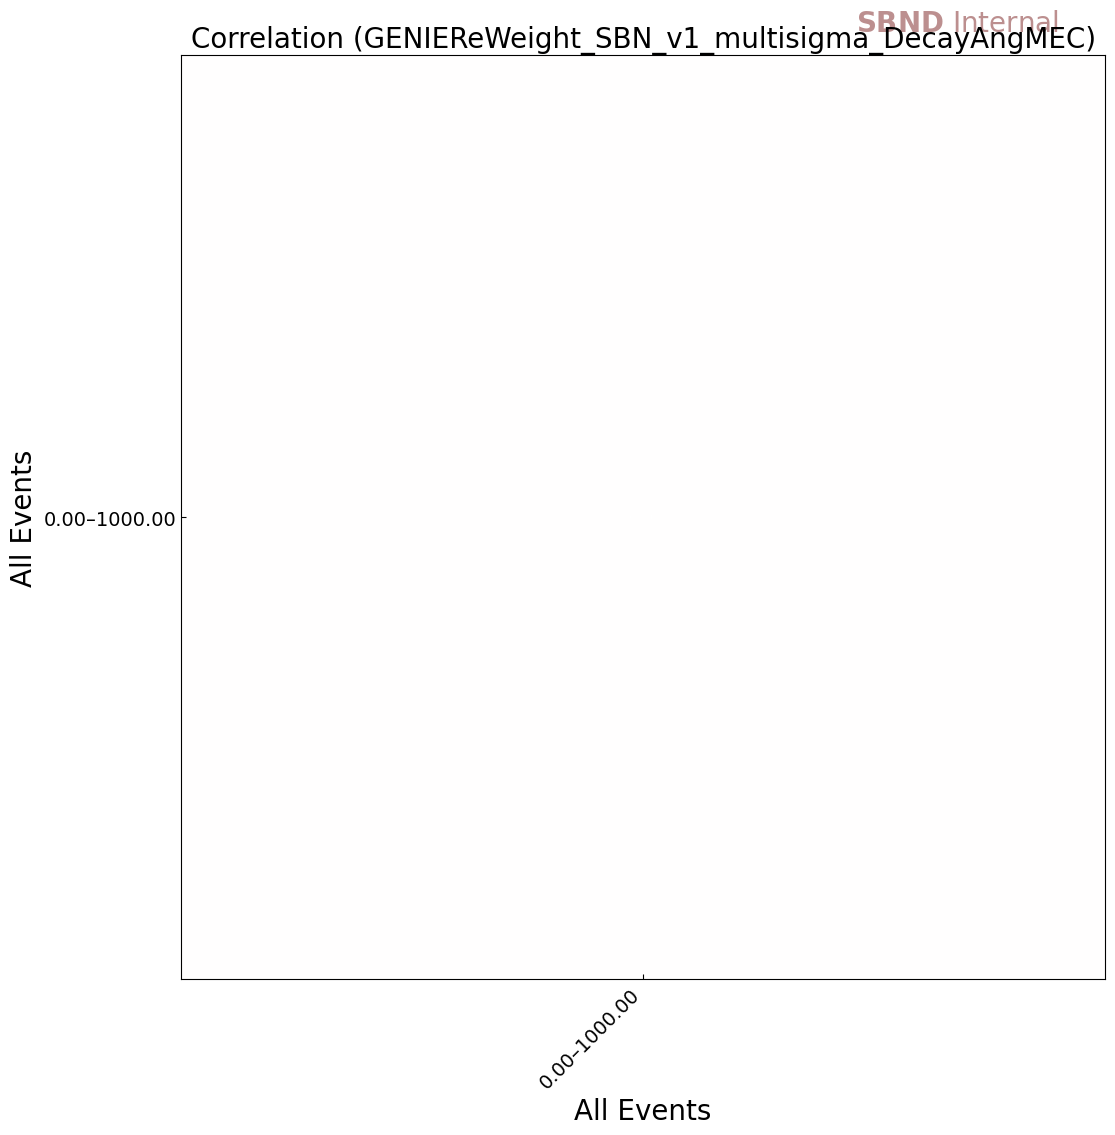

In [ ]:
slug = PLOT_VAR
vc = VAR_CONFIGS.get(slug)
assert vc is not None, f"unknown PLOT_VAR={slug!r}; choose from {sorted(VAR_CONFIGS)}"

# Prefer knobs with non-zero frac-cov (esp. important for single-bin ``integrated``).
genie_keys = [
    k for k in sorted(genie_cov.get(slug, {}))
    if k not in ("genie", "genie_rate") and k not in SLIM_SKIP and not k.endswith("_rate")
]
if slug in genie_cov and genie_keys:
    def _knob_frac_norm(kn: str) -> float:
        p = (
            genie_cov[slug].get(f"{kn}_rate") if COV_KIND == "rate"
            else genie_cov[slug].get(kn)
        ) or genie_cov[slug].get(kn)
        if p is None:
            return 0.0
        return float(np.nansum(np.abs(np.asarray(p["cov_frac"], dtype=float))))

    genie_keys = sorted(genie_keys, key=_knob_frac_norm, reverse=True)
SELECTED_KNOB = os.environ.get("NUMUCC_SYST_SELECTED_KNOB", genie_keys[0] if genie_keys else "")
print("SELECTED_KNOB =", SELECTED_KNOB)

pack = None
if slug in genie_cov:
    if COV_KIND == "rate":
        pack = genie_cov[slug].get(f"{SELECTED_KNOB}_rate") or genie_cov[slug].get(SELECTED_KNOB)
    else:
        pack = genie_cov[slug].get(SELECTED_KNOB)
if pack is None and slug in flux_cov:
    pack = flux_cov[slug].get(SELECTED_KNOB)
if pack is None and slug in g4_cov:
    pack = g4_cov[slug].get(SELECTED_KNOB)
if pack is None:
    for tag, d in detector_cov.items():
        if SELECTED_KNOB in (tag, "") and slug in d:
            pack = d[slug]
            SELECTED_KNOB = tag
            break

if pack is None:
    print("[skip] no pack for", SELECTED_KNOB, "on", slug)
else:
    cov = np.asarray(pack["cov_frac"], dtype=float)
    corr = np.asarray(pack.get("corr", pack.get("corr_frac")), dtype=float)
    if corr is None or corr.size == 0:
        d = np.sqrt(np.clip(np.diag(cov), 0, None))
        with np.errstate(divide="ignore", invalid="ignore"):
            corr = cov / np.outer(d, d)
            corr = np.nan_to_num(corr, nan=0.0)
    xlab = vc.var_labels[0] if isinstance(vc.var_labels, (list, tuple)) else str(vc.var_labels)
    plot_heatmap(
        cov, vc.bins,
        plot_labels=[xlab, xlab, f"Frac. cov ({SELECTED_KNOB})"],
        cmap="viridis",
    )
    plot_heatmap(
        corr, vc.bins,
        plot_labels=[xlab, xlab, f"Correlation ({SELECTED_KNOB})"],
        cmap="bwr",
    )

## 4. Systematic uncertainty summary — selected knobs

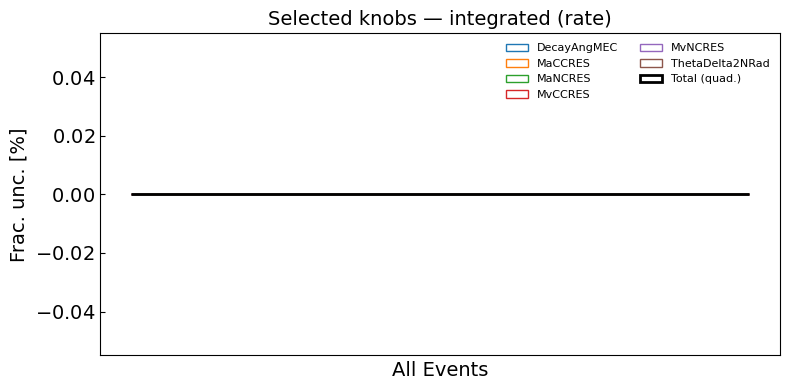

In [16]:
def plot_unc_summary(series: dict[str, np.ndarray], title: str, vc):
    """``series`` maps label → fractional unc array (same nbins)."""
    if not series:
        print("[skip]", title)
        return
    centers = np.asarray(vc.bin_centers, dtype=float)
    bins = np.asarray(vc.bins, dtype=float)
    plt.figure(figsize=(8, 4))
    # Prefer histtype=step over plt.step(centers, ...): a single bin center
    # (``integrated``) makes plt.step draw a zero-length path → blank axes.
    for label, frac in series.items():
        plt.hist(
            centers,
            bins=bins,
            weights=100.0 * np.asarray(frac, dtype=float),
            histtype="step",
            label=label,
        )
    # quadrature total if ≥2 components
    if len(series) >= 2:
        stack = np.vstack([np.asarray(v, dtype=float) ** 2 for v in series.values()])
        tot = np.sqrt(np.sum(stack, axis=0))
        plt.hist(
            centers,
            bins=bins,
            weights=100.0 * tot,
            histtype="step",
            color="k",
            lw=2,
            label="Total (quad.)",
        )
    xlab = vc.var_labels[0] if isinstance(vc.var_labels, (list, tuple)) else str(vc.var_labels)
    plt.xlabel(xlab)
    plt.ylabel("Frac. unc. [%]")
    plt.title(title)
    plt.legend(fontsize=8, ncol=2, frameon=False)
    if getattr(vc, "var_save_name", None) == "integrated" or len(centers) == 1:
        plt.xticks([])
    plt.tight_layout()
    plt.show()


# Edit this list, or leave empty to auto-pick a few GENIE knobs
SELECTED_KNOBS = []
if not SELECTED_KNOBS and slug in genie_cov:
    SELECTED_KNOBS = genie_keys[:6]

knob_series = {}
for kn in SELECTED_KNOBS:
    p = None
    if slug in genie_cov:
        p = (
            genie_cov[slug].get(f"{kn}_rate") if COV_KIND == "rate"
            else genie_cov[slug].get(kn)
        ) or genie_cov[slug].get(kn)
    if p is not None:
        short = kn.split("_")[-1] if "_" in kn else kn
        knob_series[short] = pack_frac_diag(p)

plot_unc_summary(knob_series, f"Selected knobs — {slug} ({COV_KIND})", vc)

## 5. GENIE mode summary (CCQE, MEC, …)

Sums fractional covariances of knobs belonging to each ``GENIE_KNOB_GROUPS`` mode.

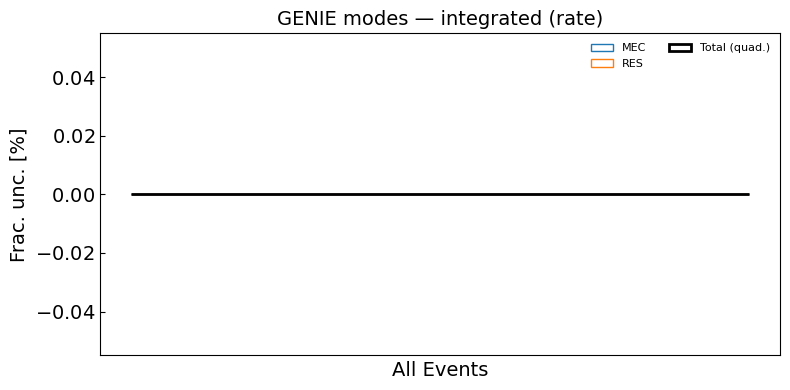

In [17]:
MODE_ORDER = ["CCQE", "ZExp", "MEC", "RES", "nonRES", "DIS", "Other", "Ar23p"]
mode_series = {}
if slug in genie_cov:
    for mode in MODE_ORDER:
        mp = sum_mode_frac_covs(genie_cov[slug], mode, kind=COV_KIND)
        if mp is not None:
            mode_series[mode] = pack_frac_diag(mp)

plot_unc_summary(mode_series, f"GENIE modes — {slug} ({COV_KIND})", vc)

## 6. All-category summary — GENIE, Flux, G4, detector, cosmics

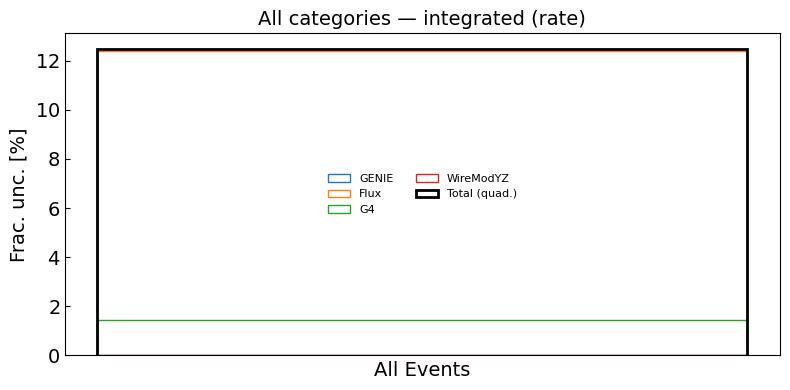

In [18]:
cat_series = {}

if slug in genie_cov:
    gkey = "genie_rate" if COV_KIND == "rate" else "genie"
    if gkey in genie_cov[slug]:
        cat_series["GENIE"] = pack_frac_diag(genie_cov[slug][gkey])

if slug in flux_cov and "flux" in flux_cov[slug]:
    cat_series["Flux"] = pack_frac_diag(flux_cov[slug]["flux"])
if slug in g4_cov and "g4" in g4_cov[slug]:
    cat_series["G4"] = pack_frac_diag(g4_cov[slug]["g4"])

# Detector: sum WireMod + DENT frac covs in quadrature via combine if CVs match
det_packs = []
det_cv = None
for tag, d in detector_cov.items():
    if slug in d:
        det_packs.append(d[slug])
        det_cv = d[slug].get("cv")
        cat_series[tag] = pack_frac_diag(d[slug])
if len(det_packs) >= 2 and det_cv is not None:
    cat_series["Detector (sum)"] = pack_frac_diag(
        combine_indep_knob_frac_covs(det_packs, det_cv)
    )

if slug in cosmics_cov:
    cat_series["Cosmics"] = pack_frac_diag(cosmics_cov[slug])

plot_unc_summary(cat_series, f"All categories — {slug} ({COV_KIND})", vc)

## Notes

* Campaign: ``syst_histcounts_full_2026_09_07_012239`` (MC GENIE / Ar23p / dirt).
* **Load path:** ``stream_sum_genie_dense(..., vars=COV_VARS)`` → ``build_genie_covs_from_dense``.
  Cov packs expose ``cov``, ``cov_frac``, ``corr``; fractional unc = ``sqrt(diag(cov_frac))``.
* ``COV_VARS`` defaults to final selected: ``integrated``, ``tki-del_Tp``, ``tki-del_alpha``, ``tki-del_phi``.
* Smoke: ``GENIE_MAX_FILES=2``. Full Spring GENIE I/O still dominates wall time.
* Flux/G4: ``NUMUCC_SYST_HIST_EXTRA_ROOTS=…`` when from-df outs are ready.
* Cosmics: ``FLAT_F`` until gate-based contamination is set.
